# Import libraries

In [29]:
import os
from re import search
from dfply import *

In [30]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Load settings

In [31]:
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/settings.py').read())
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/utils.py').read())
exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())


## Define I/O

In [32]:
io["anndata"] = io["basedir"] + "/processed/rna/anndata.h5ad"
io["metadata"] = io["basedir"] + "/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
io["outdir"] = io["basedir"] + "/results/rna/trajectories/nmp"

## Define options 

scanpy options

In [33]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.figdir = io["outdir"]
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [34]:
# opts["samples"] = [
# 	"E8.5_CRISPR_T_KO",
# 	"E8.5_CRISPR_T_WT"
# ]
# 
# 
# opts["celltypes"] = [
#   "Caudal_Mesoderm",
#   "Somitic_mesoderm",
#   "NMP",
#   "Spinal_cord"
# ]

In [35]:
opts["samples"] = [
#	"E7.5_rep1",
#	"E7.5_rep2",
#	"E7.75_rep1",
#	"E8.0_rep1",
#	"E8.0_rep2",
#	"E8.5_rep1",
#	"E8.5_rep2",
#	"E8.75_rep1",
#	"E8.75_rep2"
	"E8.5_CRISPR_T_KO",
	"E8.5_CRISPR_T_WT"
]

opts["celltypes"] = [
  "Caudal_Mesoderm",
  "Somitic_mesoderm",
  "NMP",
  "Spinal_cord"
]

## Load cell metadata

In [36]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X.pass_rnaQC==True, X.doublet_call==False) >>
    mask(X["sample"].isin(opts["samples"]), X["celltype"].isin(opts["celltypes"]))
)
metadata.shape

/Users/argelagr/opt/anaconda3/envs/main/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (8) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


(2440, 15)

In [37]:
metadata["sample"].value_counts()

E8.5_CRISPR_T_WT    1247
E8.5_CRISPR_T_KO    1193
Name: sample, dtype: int64

# Load anndata object

In [50]:
exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())

In [51]:
adata = load_adata(
    adata_file = io["anndata"], 
    cells = metadata.cell.values, 
    normalise = True, 
    set_colors = True,
    filter_lowly_expressed_genes = False
)
adata

AnnData object with n_obs × n_vars = 2440 × 32285
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype', 'celltype.score', 'closest.cell'
    var: 'gene'
    uns: 'log1p', 'celltype_colors', 'stage_colors'

In [53]:
# adata.X.todense()[:5,:5]
# adata.layers["raw"].todense()[:5,:5]

## Feature selection

In [54]:
sc.pp.highly_variable_genes(adata, layer=None, n_top_genes=1500)

# Dimensionality reduction

## PCA

Run PCA

In [55]:
sc.tl.pca(adata, n_comps=15, svd_solver='arpack')

Plot PCA

In [56]:
# sc.pl.pca(adata, components=[1,2], color=["celltype.mapped","stage"], size=25, legend_loc=None)

## Batch effect correction

In [57]:
sc.external.pp.harmony_integrate(adata, "sample", basis='X_pca', adjusted_basis='X_pca_harmony')

2022-05-08 19:25:10,440 - harmonypy - INFO - Iteration 1 of 10
2022-05-08 19:25:10,826 - harmonypy - INFO - Iteration 2 of 10
2022-05-08 19:25:11,156 - harmonypy - INFO - Iteration 3 of 10
2022-05-08 19:25:11,518 - harmonypy - INFO - Iteration 4 of 10
2022-05-08 19:25:11,890 - harmonypy - INFO - Iteration 5 of 10
2022-05-08 19:25:12,223 - harmonypy - INFO - Iteration 6 of 10
2022-05-08 19:25:12,563 - harmonypy - INFO - Iteration 7 of 10
2022-05-08 19:25:12,923 - harmonypy - INFO - Iteration 8 of 10
2022-05-08 19:25:13,295 - harmonypy - INFO - Iteration 9 of 10
2022-05-08 19:25:13,678 - harmonypy - INFO - Iteration 10 of 10
2022-05-08 19:25:14,044 - harmonypy - INFO - Stopped before convergence


## k-NN graph

Build kNN graph

In [61]:
sc.pp.neighbors(adata, n_neighbors=25, n_pcs=15, use_rep="X_pca")

### Force-directed layout

In [62]:
sc.tl.draw_graph(adata, layout='fa', init_pos=None)

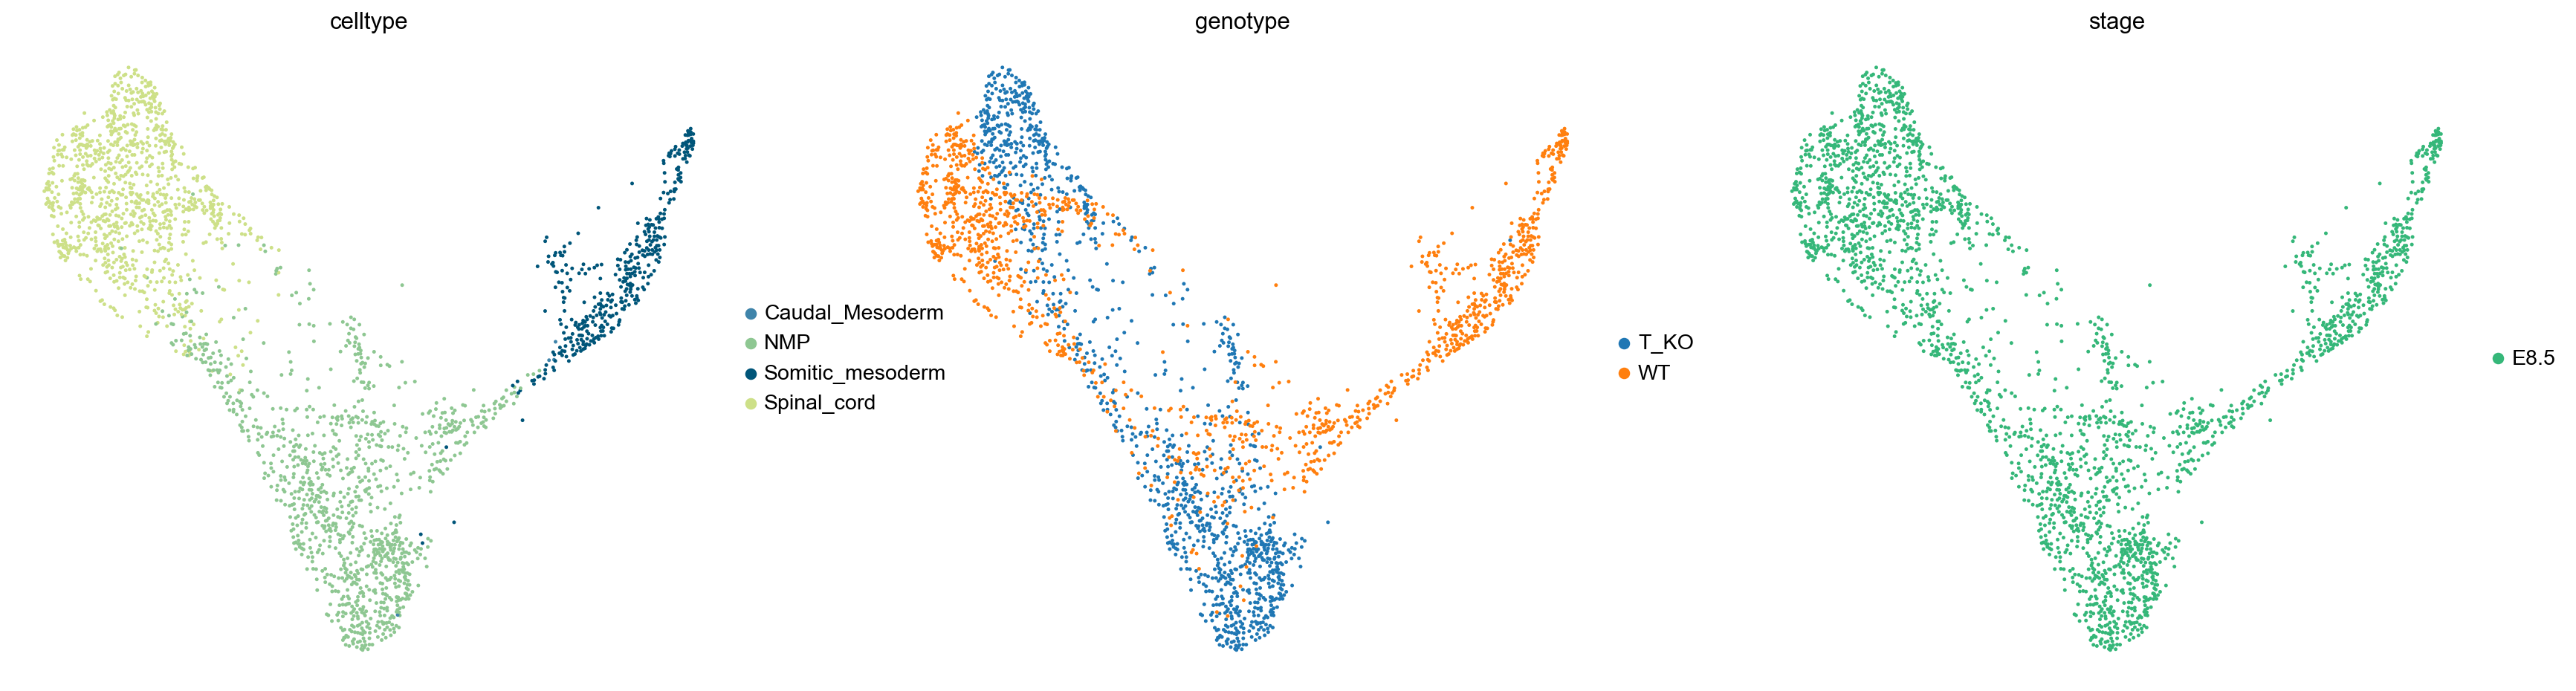

In [63]:
# legend_loc='on data', legend_fontsize=7
sc.pl.draw_graph(adata, color=["celltype","genotype","stage"], size=20, save = "nmp_trajectory.pdf")

## Save

In [ ]:
# trajectory = pd.DataFrame(adata.obsm["X_draw_graph_fa"], index=adata.obs_names, columns=["FA1","FA2"])
# trajectory.to_csv(io["outdir"] + "/nmp_trajectory.txt.gz", sep='\t')
# del adata.layers["raw"]
# adata.write(io["outdir"] + "/nmp_anndata.h5ad")
# metadata.to_csv(io["outdir"] + "/nmp_sample_metadata.txt.gz", sep='\t')

Test

In [49]:
adata.obsm

AxisArrays with keys: X_pca, X_draw_graph_fa

In [48]:
adata.obsm["X_draw_graph_fa"]

array([[-1.82815976e+03, -1.24488952e+04],
       [-3.35105738e+03,  2.69521627e+03],
       [ 5.73392813e+03,  1.49025285e+04],
       ...,
       [-2.83087249e+03, -1.55029721e+04],
       [-1.49036517e+01,  7.49974130e+02],
       [ 1.47560092e+03,  7.13452681e+02]])